### Setup and Load Data from First Notebook

In [45]:
from IPython.utils import io

with io.capture_output():
    %run ../01_eda_exploratory_data_analysis/01_data_overview.ipynb

print("✅ Connected to 01_data_overview.ipynb")

✅ Connected to 01_data_overview.ipynb


### Comprehensive Statistical Summary

In [46]:
# ====================================================================
# 📊 COMPREHENSIVE STATISTICAL SUMMARY
# ====================================================================

print("=" * 60)
print("📊 COMPREHENSIVE STATISTICAL SUMMARY")
print("=" * 60)

# All numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n📋 Numeric Columns ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  - {col}")

# Detailed statistics
display(df[numeric_cols].describe())

# Additional statistics for price
if price_col:
    data = df[price_col].dropna()
    print("\n📈 ADDITIONAL PRICE STATISTICS:")
    print(f"  Mean: {data.mean():.4f}")
    print(f"  Median: {data.median():.4f}")
    print(f"  Mode: {data.mode().iloc[0]:.4f}" if not data.mode().empty else "  Mode: N/A")
    print(f"  Std Dev: {data.std():.4f}")
    print(f"  Variance: {data.var():.4f}")
    print(f"  Range: {data.max() - data.min():.4f}")
    print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.4f}")
    print(f"  CV (Std/Mean): {data.std()/data.mean():.4f}")
    
    # Percentiles
    print(f"\n📊 PRICE PERCENTILES:")
    for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
        print(f"  {p:2d}th: {data.quantile(p/100):.4f}")

📊 COMPREHENSIVE STATISTICAL SUMMARY

📋 Numeric Columns (19):
  - open
  - high
  - low
  - close
  - volume
  - SMA_7
  - SMA_20
  - SMA_50
  - EMA_12
  - EMA_26
  - MACD
  - MACD_signal
  - MACD_histogram
  - RSI_14
  - BB_middle
  - BB_upper
  - BB_lower
  - ATR_14
  - returns


,open,high,low,close,volume,SMA_7,SMA_20,SMA_50,EMA_12,EMA_26,MACD,MACD_signal,MACD_histogram,RSI_14,BB_middle,BB_upper,BB_lower,ATR_14,returns
count,395.000000,395.000000,395.000000,395.000000,3.950000e+02,359.000000,346.000000,316.000000,365.000000,365.000000,365.000000,365.000000,365.000000,352.000000,346.000000,346.000000,346.000000,352.000000,394.000000
mean,2787.995038,2852.488354,2716.269443,2783.145013,4.046649e+05,2862.522642,2861.888386,2844.108396,2890.107533,2928.033711,-37.926179,-38.356148,0.429969,47.107936,2861.888386,3171.840862,2551.935909,146.364568,-0.105756
std,955.899833,983.000018,927.577915,955.616896,2.863877e+05,946.906726,934.113704,864.848900,936.334708,915.355395,99.767118,93.020338,31.631093,15.687701,934.113704,1047.317903,846.795635,66.712376,3.800858
min,1567.860000,1588.820000,1505.680000,1567.840000,1.177100e+04,1583.875714,1669.393500,1732.783400,1624.304782,1695.881177,-277.939829,-253.062840,-103.685809,4.287692,1669.393500,1810.826348,1451.436069,59.489286,-14.962342
25%,1967.735000,2020.575000,1918.070000,1965.545000,2.083367e+05,2038.997857,2087.789750,2120.844000,2078.425147,2112.412675,-87.299503,-90.560888,-20.666328,34.285227,2087.789750,2297.720497,1849.420766,93.255357,-2.284848
50%,2350.330000,2394.710000,2300.550000,2348.170000,3.645353e+05,2872.938571,2726.885500,2653.848200,2962.668256,3004.752990,-32.543902,-31.017265,1.177192,48.026374,2726.885500,3199.047942,2250.584511,124.374286,-0.067655
75%,3492.480000,3635.760000,3369.970000,3462.125000,5.110799e+05,3653.617857,3713.310000,3426.064950,3746.986791,3793.790000,29.989657,24.733617,22.972901,59.694854,3713.310000,4217.916519,3163.111546,186.699643,1.614953
max,4832.070000,4956.780000,4711.000000,4832.070000,2.102312e+06,4626.478571,4484.077500,4406.657600,4516.162441,4449.454562,205.877683,175.262787,112.198972,84.273261,4484.077500,5021.068056,4177.377409,317.668571,14.360400



📈 ADDITIONAL PRICE STATISTICS:
  Mean: 2783.1450
  Median: 2348.1700
  Mode: 1808.0000
  Std Dev: 955.6169
  Variance: 913203.6524
  Range: 3264.2300
  IQR: 1496.5800
  CV (Std/Mean): 0.3434

📊 PRICE PERCENTILES:
   1th: 1573.8712
   5th: 1709.8590
  10th: 1797.9340
  25th: 1965.5450
  50th: 2348.1700
  75th: 3462.1250
  90th: 4321.7000
  95th: 4491.3920
  99th: 4714.3884


### Distribution Analysis

In [47]:
# ====================================================================
# 📊 DISTRIBUTION ANALYSIS
# ====================================================================

# Import required statistical functions
from scipy.stats import skew, kurtosis, jarque_bera, shapiro, normaltest

if price_col:
    data = df[price_col].dropna()
    returns = df['returns'].dropna() if 'returns' in df.columns else None
    
    print("=" * 60)
    print("📊 DISTRIBUTION ANALYSIS")
    print("=" * 60)
    
    # =================================================================
    # PRICE DISTRIBUTION
    # =================================================================
    print("\n📈 PRICE DISTRIBUTION:")
    print("-" * 40)
    
    skewness = skew(data)
    kurt = kurtosis(data)
    
    print(f"  Skewness: {skewness:.4f}")
    if abs(skewness) < 0.5:
        print("    → Approximately Symmetric (Balanced distribution)")
    elif skewness > 0:
        print("    → Positively Skewed (Right-tailed, more high values)")
    else:
        print("    → Negatively Skewed (Left-tailed, more low values)")
    
    print(f"  Kurtosis: {kurt:.4f}")
    if kurt > 3:
        print("    → Leptokurtic (Heavy tails, more outliers/extreme values)")
    elif kurt < 3:
        print("    → Platykurtic (Light tails, fewer outliers)")
    else:
        print("    → Mesokurtic (Normal-like distribution)")
    
    print(f"\n  Additional Price Stats:")
    print(f"    Mean: {data.mean():.4f}")
    print(f"    Median: {data.median():.4f}")
    print(f"    Std Dev: {data.std():.4f}")
    print(f"    Range: {data.max() - data.min():.4f}")
    
    # =================================================================
    # RETURNS DISTRIBUTION
    # =================================================================
    if returns is not None and len(returns) > 0:
        print("\n📈 RETURNS DISTRIBUTION:")
        print("-" * 40)
        
        skewness_r = skew(returns)
        kurt_r = kurtosis(returns)
        
        print(f"  Skewness: {skewness_r:.4f}")
        if abs(skewness_r) < 0.5:
            print("    → Approximately Symmetric")
        elif skewness_r > 0:
            print("    → Positively Skewed (More positive extreme returns)")
        else:
            print("    → Negatively Skewed (More negative extreme returns)")
        
        print(f"  Kurtosis: {kurt_r:.4f}")
        if kurt_r > 3:
            print("    → Leptokurtic (Fat tails, frequent extreme events)")
        elif kurt_r < 3:
            print("    → Platykurtic (Thin tails, fewer extreme events)")
        else:
            print("    → Mesokurtic (Normal-like)")
        
        print(f"\n  Additional Returns Stats (%):")
        print(f"    Mean: {returns.mean():.6f}")
        print(f"    Median: {returns.median():.6f}")
        print(f"    Std Dev: {returns.std():.6f}")
        print(f"    Min: {returns.min():.6f}")
        print(f"    Max: {returns.max():.6f}")
    
    # =================================================================
    # NORMALITY TESTS
    # =================================================================
    print("\n🔍 NORMALITY TESTS:")
    print("-" * 40)
    
    # 1. Jarque-Bera test
    try:
        jb_stat, jb_p = jarque_bera(data)
        print(f"  Jarque-Bera:")
        print(f"    Test Statistic: {jb_stat:.4f}")
        print(f"    P-value: {jb_p:.4f}")
        if jb_p > 0.05:
            print("    → Fail to reject normality (data appears normal)")
        else:
            print("    → Reject normality (data not normal)")
    except Exception as e:
        print(f"  Jarque-Bera: Error - {e}")
    
    # 2. D'Agostino's K^2 test
    try:
        dag_stat, dag_p = normaltest(data)
        print(f"\n  D'Agostino's K^2:")
        print(f"    Test Statistic: {dag_stat:.4f}")
        print(f"    P-value: {dag_p:.4f}")
        if dag_p > 0.05:
            print("    → Fail to reject normality (data appears normal)")
        else:
            print("    → Reject normality (data not normal)")
    except Exception as e:
        print(f"  D'Agostino's K^2: Error - {e}")
    
    # 3. Shapiro-Wilk test (limited to 5000 samples)
    try:
        if len(data) <= 5000:
            sample_size = min(5000, len(data))
            sample_data = data.sample(n=sample_size, random_state=42) if len(data) > sample_size else data
            shapiro_stat, shapiro_p = shapiro(sample_data)
            print(f"\n  Shapiro-Wilk:")
            print(f"    Test Statistic: {shapiro_stat:.4f}")
            print(f"    P-value: {shapiro_p:.4f}")
            print(f"    Sample Size: {sample_size}")
            if shapiro_p > 0.05:
                print("    → Fail to reject normality (data appears normal)")
            else:
                print("    → Reject normality (data not normal)")
    except Exception as e:
        print(f"  Shapiro-Wilk: Error - {e}")
    
    # =================================================================
    # SUMMARY INTERPRETATION
    # =================================================================
    print("\n📌 INTERPRETATION SUMMARY:")
    print("-" * 40)
    
    # Check if data is normal based on majority of tests
    normal_tests = []
    try:
        if jb_p > 0.05:
            normal_tests.append(True)
        else:
            normal_tests.append(False)
    except:
        pass
    
    try:
        if dag_p > 0.05:
            normal_tests.append(True)
        else:
            normal_tests.append(False)
    except:
        pass
    
    if normal_tests:
        normal_count = sum(normal_tests)
        total_tests = len(normal_tests)
        
        if normal_count / total_tests > 0.5:
            print("  ✅ Data appears to follow a normal distribution")
            print(f"     {normal_count}/{total_tests} tests indicate normality")
        else:
            print("  ⚠️  Data deviates from normal distribution")
            print(f"     {normal_count}/{total_tests} tests indicate normality")
    
    # Tail risk assessment
    if returns is not None:
        print(f"\n  📊 Tail Risk Assessment:")
        extreme_positive = (returns > 3 * returns.std()).sum()
        extreme_negative = (returns < -3 * returns.std()).sum()
        total_extreme = extreme_positive + extreme_negative
        pct_extreme = (total_extreme / len(returns)) * 100
        
        print(f"    Extreme Events (>3σ): {total_extreme} ({pct_extreme:.2f}%)")
        print(f"    Extreme Positive: {extreme_positive}")
        print(f"    Extreme Negative: {extreme_negative}")
        
        if pct_extreme > 1:
            print("    → Significant tail risk detected")
        else:
            print("    → Limited tail risk")
    
    print("\n" + "=" * 60)

📊 DISTRIBUTION ANALYSIS

📈 PRICE DISTRIBUTION:
----------------------------------------
  Skewness: 0.5884
    → Positively Skewed (Right-tailed, more high values)
  Kurtosis: -1.0336
    → Platykurtic (Light tails, fewer outliers)

  Additional Price Stats:
    Mean: 2783.1450
    Median: 2348.1700
    Std Dev: 955.6169
    Range: 3264.2300

📈 RETURNS DISTRIBUTION:
----------------------------------------
  Skewness: 0.3133
    → Approximately Symmetric
  Kurtosis: 2.6789
    → Platykurtic (Thin tails, fewer extreme events)

  Additional Returns Stats (%):
    Mean: -0.105756
    Median: -0.067655
    Std Dev: 3.800858
    Min: -14.962342
    Max: 14.360400

🔍 NORMALITY TESTS:
----------------------------------------
  Jarque-Bera:
    Test Statistic: 40.3761
    P-value: 0.0000
    → Reject normality (data not normal)

  D'Agostino's K^2:
    Test Statistic: 110.8941
    P-value: 0.0000
    → Reject normality (data not normal)

  Shapiro-Wilk:
    Test Statistic: 0.8885
    P-value: 

Returns Analysis

In [48]:
# ====================================================================
# 📊 RETURNS ANALYSIS
# ====================================================================

if price_col:
    # Calculate returns if not already done
    if 'returns' not in df.columns:
        df['returns'] = df[price_col].pct_change() * 100
        df['log_returns'] = np.log(df[price_col] / df[price_col].shift(1)) * 100
        df['cumulative'] = (df[price_col] / df[price_col].iloc[0] - 1) * 100
        print("✅ Calculated returns columns")
    
    # Check which columns exist
    has_returns = 'returns' in df.columns
    has_log_returns = 'log_returns' in df.columns
    has_cumulative = 'cumulative' in df.columns
    
    print("=" * 60)
    print("📊 RETURNS ANALYSIS")
    print("=" * 60)
    
    # Simple Returns
    if has_returns:
        returns = df['returns'].dropna()
        print("\n📈 SIMPLE RETURNS (%):")
        print(f"  Mean: {returns.mean():.6f}")
        print(f"  Median: {returns.median():.6f}")
        print(f"  Std Dev: {returns.std():.6f}")
        print(f"  Min: {returns.min():.6f}")
        print(f"  Max: {returns.max():.6f}")
        
        # Check if skew and kurtosis functions exist
        try:
            from scipy.stats import skew, kurtosis
            print(f"  Skewness: {skew(returns):.4f}")
            print(f"  Kurtosis: {kurtosis(returns):.4f}")
        except:
            print("  Skewness: N/A (scipy not available)")
            print("  Kurtosis: N/A (scipy not available)")
    else:
        print("\n⚠️  'returns' column not found")
    
    # Log Returns
    if has_log_returns:
        log_returns = df['log_returns'].dropna()
        print("\n📈 LOG RETURNS (%):")
        print(f"  Mean: {log_returns.mean():.6f}")
        print(f"  Median: {log_returns.median():.6f}")
        print(f"  Std Dev: {log_returns.std():.6f}")
        print(f"  Min: {log_returns.min():.6f}")
        print(f"  Max: {log_returns.max():.6f}")
    else:
        print("\n⚠️  'log_returns' column not found")
    
    # Performance Metrics
    if has_returns and has_cumulative:
        cumulative = df['cumulative'].dropna()
        returns = df['returns'].dropna()
        
        print("\n📊 PERFORMANCE METRICS:")
        total_return = cumulative.iloc[-1]
        avg_daily_return = returns.mean()
        volatility = returns.std()
        
        print(f"  Total Return: {total_return:.2f}%")
        print(f"  Annualized Return (252 days): {avg_daily_return * 252:.2f}%")
        print(f"  Annualized Volatility: {volatility * np.sqrt(252):.2f}%")
        
        # Sharpe Ratio (assuming 0% risk-free rate)
        if returns.std() > 0:
            sharpe = returns.mean() / returns.std()
            sharpe_annual = sharpe * np.sqrt(252)
            print(f"  Sharpe Ratio (Daily): {sharpe:.4f}")
            print(f"  Sharpe Ratio (Annualized): {sharpe_annual:.4f}")
        else:
            print("  Sharpe Ratio: N/A (zero volatility)")
        
        # Win/Loss analysis
        positive = (returns > 0).sum()
        negative = (returns < 0).sum()
        zero = (returns == 0).sum()
        
        print(f"\n📊 WIN/LOSS ANALYSIS:")
        print(f"  Positive Days: {positive} ({positive/len(returns)*100:.1f}%)")
        print(f"  Negative Days: {negative} ({negative/len(returns)*100:.1f}%)")
        print(f"  Zero Days: {zero} ({zero/len(returns)*100:.1f}%)")
        
        # Average wins and losses
        avg_win = returns[returns > 0].mean() if (returns > 0).sum() > 0 else 0
        avg_loss = returns[returns < 0].mean() if (returns < 0).sum() > 0 else 0
        
        print(f"\n  Average Win: {avg_win:.4f}%")
        print(f"  Average Loss: {avg_loss:.4f}%")
        if avg_loss != 0:
            print(f"  Win/Loss Ratio: {abs(avg_win/avg_loss):.2f}")
        else:
            print("  Win/Loss Ratio: N/A")
        
        # Profit Factor
        total_gains = returns[returns > 0].sum()
        total_losses = abs(returns[returns < 0].sum())
        if total_losses > 0:
            profit_factor = abs(total_gains / total_losses)
            print(f"  Profit Factor: {profit_factor:.2f}")
        else:
            print("  Profit Factor: N/A")
    else:
        print("\n⚠️  Missing columns for performance metrics")
        print(f"  Has returns: {has_returns}")
        print(f"  Has cumulative: {has_cumulative}")

📊 RETURNS ANALYSIS

📈 SIMPLE RETURNS (%):
  Mean: -0.105756
  Median: -0.067655
  Std Dev: 3.800858
  Min: -14.962342
  Max: 14.360400
  Skewness: 0.3133
  Kurtosis: 2.6789

⚠️  'log_returns' column not found

⚠️  Missing columns for performance metrics
  Has returns: True
  Has cumulative: False


Correlation Analysis

📊 CORRELATION ANALYSIS

📈 CORRELATION MATRIX:


,open,high,low,close,volume,returns,RSI_14,MACD,ATR_14
open,1.000000,0.997475,0.995835,0.994115,0.343994,-0.034500,0.151922,0.343656,0.716161
high,0.997475,1.000000,0.995574,0.997671,0.363985,0.010164,0.160288,0.339934,0.726507
low,0.995835,0.995574,1.000000,0.997506,0.292576,0.022863,0.175596,0.358455,0.698265
close,0.994115,0.997671,0.997506,1.000000,0.326215,0.053646,0.175254,0.348197,0.711870
volume,0.343994,0.363985,0.292576,0.326215,1.000000,-0.166070,-0.216951,-0.189199,0.520108
returns,-0.034500,0.010164,0.022863,0.053646,-0.166070,1.000000,0.258766,0.071596,0.002715
RSI_14,0.151922,0.160288,0.175596,0.175254,-0.216951,0.258766,1.000000,0.644118,-0.158873
MACD,0.343656,0.339934,0.358455,0.348197,-0.189199,0.071596,0.644118,1.000000,-0.136340
ATR_14,0.716161,0.726507,0.698265,0.711870,0.520108,0.002715,-0.158873,-0.136340,1.000000



🔍 HIGH CORRELATIONS (>0.8 or <-0.8):
  open            ↔ high            : 0.9975
  open            ↔ low             : 0.9958
  open            ↔ close           : 0.9941
  high            ↔ low             : 0.9956
  high            ↔ close           : 0.9977
  low             ↔ close           : 0.9975


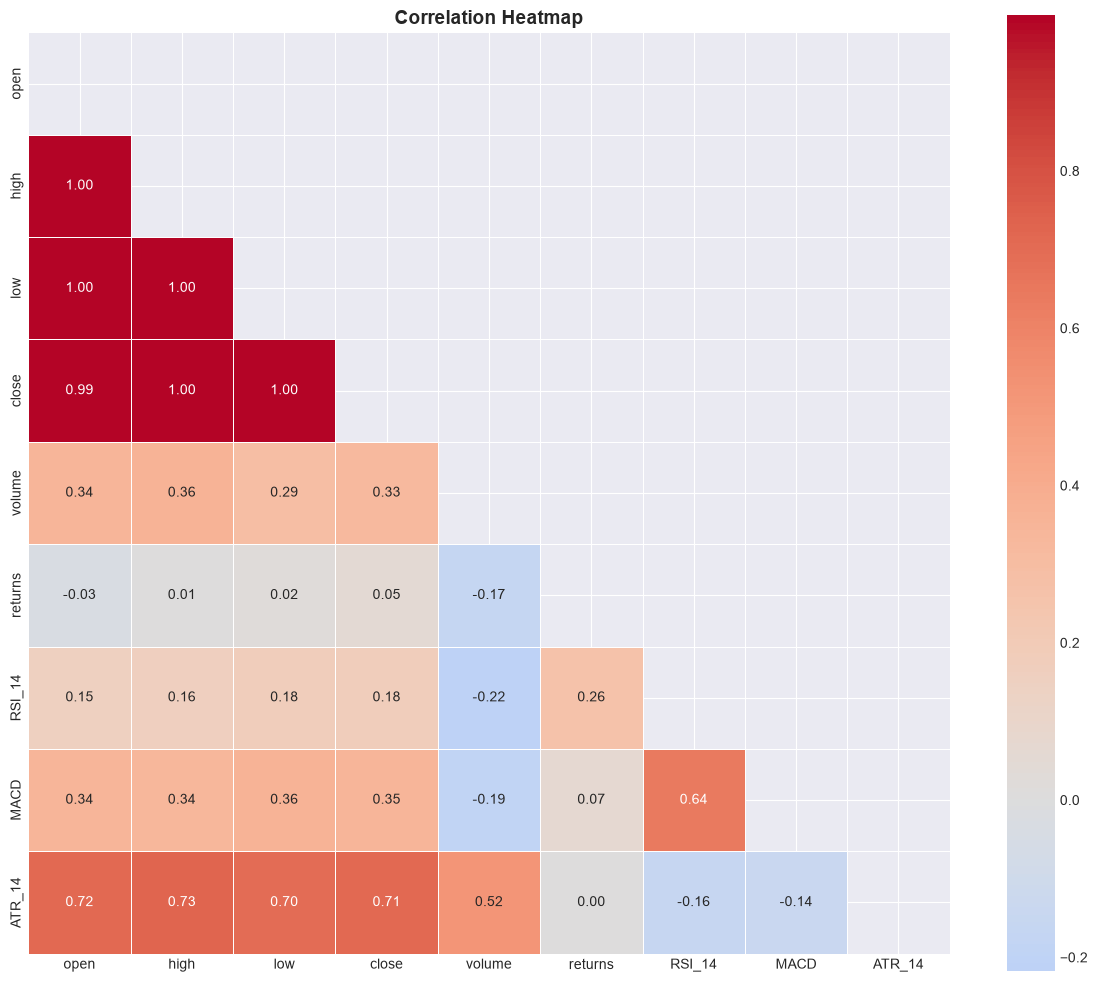

In [49]:
# ====================================================================
# 📊 CORRELATION ANALYSIS
# ====================================================================

print("=" * 60)
print("📊 CORRELATION ANALYSIS")
print("=" * 60)

# Select key columns for correlation
corr_cols = []
for col in ['open', 'high', 'low', 'close', 'volume', 'returns', 'log_returns']:
    if col in df.columns:
        corr_cols.append(col)

# Add technical indicators
for col in ['RSI_14', 'MACD', 'ATR_14']:
    if col in df.columns:
        corr_cols.append(col)

if len(corr_cols) > 1:
    # Correlation matrix
    corr_matrix = df[corr_cols].corr()
    
    print("\n📈 CORRELATION MATRIX:")
    display(corr_matrix)
    
    # High correlations
    print("\n🔍 HIGH CORRELATIONS (>0.8 or <-0.8):")
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            val = corr_matrix.iloc[i, j]
            if abs(val) > 0.8:
                print(f"  {corr_matrix.columns[i]:15s} ↔ {corr_matrix.columns[j]:15s} : {val:.4f}")
    
    # Correlation heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=0.5, ax=ax)
    ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Visualization 

In [52]:
# ====================================================================
# 🔍 DEBUG: Check Available Data
# ====================================================================

print("=" * 60)
print("🔍 CHECKING AVAILABLE DATA")
print("=" * 60)

# Check columns
print("\n📋 Columns available:")
for col in df.columns:
    print(f"  - {col}")

# Check price column
print(f"\n📊 Price column: '{price_col}'")
print(f"  Data type: {df[price_col].dtype}")
print(f"  Non-null count: {df[price_col].notna().sum()}")
print(f"  Min: {df[price_col].min():.4f}")
print(f"  Max: {df[price_col].max():.4f}")

# Check returns
if 'returns' in df.columns:
    returns_data = df['returns'].dropna()
    print(f"\n📊 Returns column:")
    print(f"  Non-null count: {returns_data.notna().sum()}")
    print(f"  Mean: {returns_data.mean():.6f}")
    print(f"  Std: {returns_data.std():.6f}")
else:
    print("\n⚠️  'returns' column not found")

# Check cumulative
if 'cumulative' in df.columns:
    print(f"\n📊 Cumulative column:")
    print(f"  Total return: {df['cumulative'].iloc[-1]:.2f}%")
else:
    print("\n⚠️  'cumulative' column not found")

print("\n" + "=" * 60)

🔍 CHECKING AVAILABLE DATA

📋 Columns available:
  - open
  - high
  - low
  - close
  - volume
  - SMA_7
  - SMA_20
  - SMA_50
  - EMA_12
  - EMA_26
  - MACD
  - MACD_signal
  - MACD_histogram
  - RSI_14
  - BB_middle
  - BB_upper
  - BB_lower
  - ATR_14
  - returns

📊 Price column: 'close'
  Data type: float64
  Non-null count: 395
  Min: 1567.8400
  Max: 4832.0700

📊 Returns column:
  Non-null count: 394
  Mean: -0.105756
  Std: 3.800858

⚠️  'cumulative' column not found



Summary 

In [ ]:
# ====================================================================
# 🔍 DEBUG: Check Available Data
# ====================================================================

print("=" * 60)
print("🔍 CHECKING AVAILABLE DATA")
print("=" * 60)

# Check columns
print("\n📋 Columns available:")
for col in df.columns:
    print(f"  - {col}")

# Check price column
print(f"\n📊 Price column: '{price_col}'")
print(f"  Data type: {df[price_col].dtype}")
print(f"  Non-null count: {df[price_col].notna().sum()}")
print(f"  Min: {df[price_col].min():.4f}")
print(f"  Max: {df[price_col].max():.4f}")

# Check returns
if 'returns' in df.columns:
    returns_data = df['returns'].dropna()
    print(f"\n📊 Returns column:")
    print(f"  Non-null count: {returns_data.notna().sum()}")
    print(f"  Mean: {returns_data.mean():.6f}")
    print(f"  Std: {returns_data.std():.6f}")
else:
    print("\n⚠️  'returns' column not found")

# Check cumulative
if 'cumulative' in df.columns:
    print(f"\n📊 Cumulative column:")
    print(f"  Total return: {df['cumulative'].iloc[-1]:.2f}%")
else:
    print("\n⚠️  'cumulative' column not found")

print("\n" + "=" * 60)

📊 STATISTICAL SUMMARY REPORT


,Metric,Value
0,Total Records,395
1,Start Date,2025-07-29
2,End Date,2026-07-28
3,Current Price,1883.4300
4,Mean Price,2783.1450
5,Median Price,2348.1700
6,Std Dev Price,955.6169
7,Price Range,3264.2300
8,Total Return (%),N/A
9,Avg Daily Return (%),-0.105756%



✅ Summary saved to: ..\..\exports\reports\statistical_analysis_summary.csv

✅ STATISTICAL ANALYSIS COMPLETE
